# **HACKATON**

In [1]:
# MAIN IMPORTS
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

## *OG visualisation*

DATASET EXPLORATION

Dataset shape: (73542, 789)
Total recordings: 73,542

PATIENT INFORMATION
Number of patients: 14

Recordings per patient:
  Mean: 5253.0
  Median: 4765.5
  Min: 1407
  Max: 13946

LABEL DISTRIBUTION
Overall:
  Stable (0): 62,614 (85.1%)
  Pre-hospitalization (1): 10,928 (14.9%)

Per patient:
  patient_0000: 6654 stable, 722 pre-hosp (9.8% positive)
  patient_0001: 3985 stable, 818 pre-hosp (17.0% positive)
  patient_0002: 13332 stable, 614 pre-hosp (4.4% positive)
  patient_0003: 2729 stable, 910 pre-hosp (25.0% positive)
  patient_0004: 5223 stable, 397 pre-hosp (7.1% positive)
  patient_0005: 5525 stable, 675 pre-hosp (10.9% positive)
  patient_0006: 2004 stable, 845 pre-hosp (29.7% positive)
  patient_0007: 1135 stable, 272 pre-hosp (19.3% positive)
  patient_0008: 1319 stable, 393 pre-hosp (23.0% positive)
  patient_0009: 2263 stable, 643 pre-hosp (22.1% positive)
  patient_0010: 3763 stable, 965 pre-hosp (20.4% positive)
  patient_0011: 1393 stable, 1309 pre-h

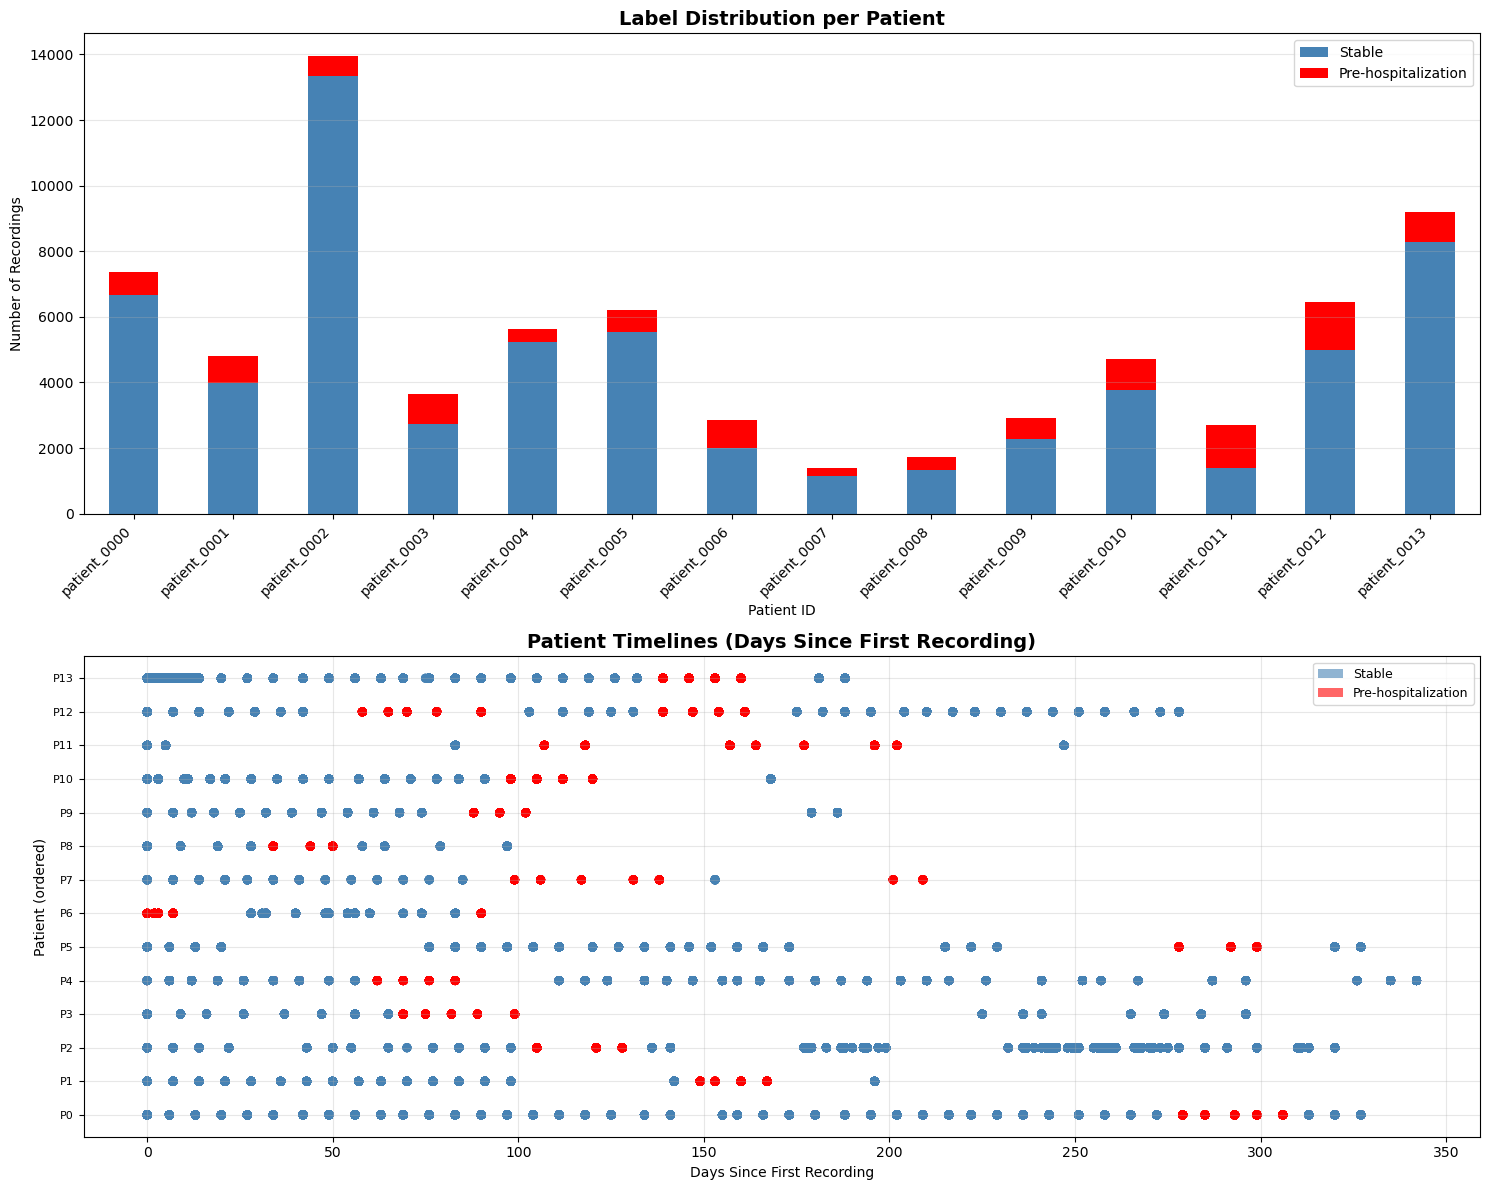


EXPLORATION COMPLETE

Key takeaways:
1. Dataset is imbalanced (more stable than pre-hospitalization recordings)
2. Patients have varying numbers of recordings and follow-up periods
3. Temporal information is available - use it for modeling!
4. Recording dates extracted from recording_id show clear temporal patterns

Next steps:
- Run: python src/train.py (to train baseline model)
- Modify: src/models.py (to improve the embedding model)
- Experiment with temporal modeling and patient-specific features!


In [25]:
"""
Data exploration script.

Run this to understand the dataset structure before diving into modeling.
"""

import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path to import utils
sys.path.insert(0, "src")
from src.utils import extract_date_from_recording_id


def explore_dataset(data_path="data/dataset.parquet"):
    """Explore the dataset and print useful statistics."""

    print("=" * 70)
    print("DATASET EXPLORATION")
    print("=" * 70)

    # Load data
    df = pd.read_parquet(data_path)
    print(f"\nDataset shape: {df.shape}")
    print(f"Total recordings: {len(df):,}")

    # Patient information
    print(f"\n{'=' * 70}")
    print("PATIENT INFORMATION")
    print("=" * 70)
    unique_patients = df["patient_short_id"].unique()
    print(f"Number of patients: {len(unique_patients)}")

    # Recordings per patient
    recordings_per_patient = df.groupby("patient_short_id").size()
    print("\nRecordings per patient:")
    print(f"  Mean: {recordings_per_patient.mean():.1f}")
    print(f"  Median: {recordings_per_patient.median():.1f}")
    print(f"  Min: {recordings_per_patient.min()}")
    print(f"  Max: {recordings_per_patient.max()}")

    # Label distribution
    print(f"\n{'=' * 70}")
    print("LABEL DISTRIBUTION")
    print("=" * 70)
    label_counts = df["label"].value_counts()
    print("Overall:")
    print(f"  Stable (0): {label_counts[0]:,} ({label_counts[0] / len(df) * 100:.1f}%)")
    print(
        f"  Pre-hospitalization (1): {label_counts[1]:,} ({label_counts[1] / len(df) * 100:.1f}%)"
    )

    print("\nPer patient:")
    for patient in sorted(unique_patients):
        patient_df = df[df["patient_short_id"] == patient]
        patient_labels = patient_df["label"].value_counts()
        n_stable = patient_labels.get(0, 0)
        n_prehosp = patient_labels.get(1, 0)
        print(
            f"  {patient}: {n_stable} stable, {n_prehosp} pre-hosp "
            f"({n_prehosp / (n_stable + n_prehosp) * 100:.1f}% positive)"
        )

    # Temporal information
    print(f"\n{'=' * 70}")
    print("TEMPORAL INFORMATION")
    print("=" * 70)

    # Extract dates from recording_id
    df["recording_date"] = extract_date_from_recording_id(df["recording_id"])

    print("\nRecording date range:")
    print(f"  First recording: {df['recording_date'].min().date()}")
    print(f"  Last recording: {df['recording_date'].max().date()}")
    print(
        f"  Total span: {(df['recording_date'].max() - df['recording_date'].min()).days} days"
    )

    print("\nFollow-up period per patient:")
    for patient in sorted(unique_patients):
        patient_df = df[df["patient_short_id"] == patient]
        first_date = patient_df["recording_date"].min()
        last_date = patient_df["recording_date"].max()
        follow_up_days = (last_date - first_date).days
        n_recordings = len(patient_df)
        print(
            f"  {patient}: {follow_up_days} days ({first_date.date()} to {last_date.date()}), {n_recordings} recordings"
        )

    # Feature information
    print(f"\n{'=' * 70}")
    print("FEATURE INFORMATION")
    print("=" * 70)

    metadata_cols = [
        "recording_id",
        "patient_short_id",
        "label",
        "recording_date",  # Added by our extraction
    ]
    feature_cols = [col for col in df.columns if col not in metadata_cols]

    print(f"Number of acoustic features: {len(feature_cols)}")
    print("\nFeature categories:")

    # Count feature types
    feature_types = {}
    for col in feature_cols:
        feature_type = col.split("_")[0]
        feature_types[feature_type] = feature_types.get(feature_type, 0) + 1

    for ftype, count in sorted(feature_types.items()):
        print(f"  {ftype}: {count} features")

    # Check for missing values
    print(f"\n{'=' * 70}")
    print("DATA QUALITY")
    print("=" * 70)

    missing_counts = df[feature_cols].isnull().sum()
    if missing_counts.sum() > 0:
        print(f"Features with missing values: {(missing_counts > 0).sum()}")
        print(f"Total missing values: {missing_counts.sum()}")
    else:
        print("No missing values in features!")

    # Create visualizations
    print(f"\n{'=' * 70}")
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    fig, axes = plt.subplots(2, 1, figsize=(15, 12))

    # 1. Label distribution per patient
    ax = axes[0]
    label_dist = df.groupby(["patient_short_id", "label"]).size().unstack(fill_value=0)
    label_dist.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "red"])
    ax.set_title("Label Distribution per Patient", fontsize=14, fontweight="bold")
    ax.set_xlabel("Patient ID")
    ax.set_ylabel("Number of Recordings")
    ax.legend(["Stable", "Pre-hospitalization"])
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    # 2. Temporal distribution per patient timeline
    ax = axes[1]
    for i, patient in enumerate(sorted(unique_patients)):
        patient_df = df[df["patient_short_id"] == patient].sort_values("recording_date")
        # Normalize dates to days since first recording for this patient
        first_date = patient_df["recording_date"].min()
        patient_df["days_since_start"] = (
            patient_df["recording_date"] - first_date
        ).dt.days

        colors = ["steelblue" if label == 0 else "red" for label in patient_df["label"]]
        ax.scatter(
            patient_df["days_since_start"],
            [i] * len(patient_df),
            c=colors,
            alpha=0.6,
            s=30,
            label=patient if i < 5 else None,  # Only label first 5 for legend
        )

    ax.set_title(
        "Patient Timelines (Days Since First Recording)", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Days Since First Recording")
    ax.set_ylabel("Patient (ordered)")
    ax.set_yticks(range(len(unique_patients)))
    ax.set_yticklabels([f"P{i}" for i in range(len(unique_patients))], fontsize=8)
    if len(unique_patients) <= 5:
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    # Add custom legend for colors
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor="steelblue", alpha=0.6, label="Stable"),
        Patch(facecolor="red", alpha=0.6, label="Pre-hospitalization"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("data_exploration.png", dpi=300, bbox_inches="tight")
    print("\nVisualization saved to: data_exploration.png")
    plt.show()

    print(f"\n{'=' * 70}")
    print("EXPLORATION COMPLETE")
    print("=" * 70)
    print("\nKey takeaways:")
    print("1. Dataset is imbalanced (more stable than pre-hospitalization recordings)")
    print("2. Patients have varying numbers of recordings and follow-up periods")
    print("3. Temporal information is available - use it for modeling!")
    print("4. Recording dates extracted from recording_id show clear temporal patterns")
    print("\nNext steps:")
    print("- Run: python src/train.py (to train baseline model)")
    print("- Modify: src/models.py (to improve the embedding model)")
    print("- Experiment with temporal modeling and patient-specific features!")


if __name__ == "__main__":
    explore_dataset()


## Training

In [2]:
# In a notebook cell
from config import get_config

base_cfg = get_config()

# --- Config dictionaries for sweeps/experiments ---
CONFIG_UPDATES = {
    # 1) Very fast sanity check (runs quickly, minimal outputs)
    "debug_fast": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 2,
        "num_epochs": 2,
        "learning_rate": 1e-3,
        "dropout": 0.1,
        "save_embeddings": False,
        "plot_embeddings": False,
        "save_model": False,
        "use_cuda": False,   # set True if you want GPU
    },

    # 2) Quick training + visualization (good for iterating on pipeline)
    "quick_viz": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 4,
        "num_epochs": 5,
        "learning_rate": 1e-3,
        "dropout": 0.2,
        "save_embeddings": True,
        "plot_embeddings": True,
        "save_model": False,
    },

    # 3) Baseline (close to your defaults, but slightly more stable)
    "baseline": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 30,
        "learning_rate": 1e-3,
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "save_embeddings": True,
        "plot_embeddings": True,
        "save_model": False,
    },

    # 4) Small model (faster, less capacity; useful to check overfitting)
    "small_model": {
        "data_path" : "../data/dataset.parquet",
        "chunk_hidden": 64,
        "day_dim": 64,
        "max_T_emb": 64,
        "batch_size": 16,
        "num_epochs": 30,
        "learning_rate": 1e-3,
        "dropout": 0.2,
        "weight_decay": 1e-4,
    },

    # 5) Larger model (more capacity; may help if underfitting)
    "large_model": {
        "data_path" : "../data/dataset.parquet",
        "chunk_hidden": 256,
        "day_dim": 256,
        "max_T_emb": 128,
        "batch_size": 10,        # reduce a bit for memory
        "num_epochs": 40,
        "learning_rate": 8e-4,
        "dropout": 0.3,
        "weight_decay": 1e-4,
    },

    # 6) Strong regularization (if you see overfitting)
    "regularized": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 40,
        "learning_rate": 8e-4,
        "dropout": 0.5,
        "weight_decay": 1e-3,
        "early_stopping": True,
        "patience": 8,
    },

    # 7) Low dropout + lower LR (often stabilizes transformers/attention stacks)
    "stable_low_lr": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 40,
        "learning_rate": 3e-4,
        "dropout": 0.1,
        "weight_decay": 1e-4,
        "early_stopping": True,
        "patience": 10,
    },

    # 8) Class imbalance aware (turn on if labels are skewed)
    "class_weighted": {
        "data_path" : "../data/dataset.parquet",
        "batch_size": 14,
        "num_epochs": 35,
        "learning_rate": 8e-4,
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "use_class_weights": True,
    },
}

# --- Build actual Config objects ---
EXPERIMENT_CONFIGS = {name: base_cfg.model_copy(update=upd) for name, upd in CONFIG_UPDATES.items()}

# Example usage:
cfg = EXPERIMENT_CONFIGS["quick_viz"]
cfg.print_config()



CONFIGURATION
  data_path: ../data/dataset.parquet
  chunk_hidden: 128
  day_dim: 128
  max_T_emb: 64
  dropout: 0.2
  gap_days: 1
  batch_size: 4
  num_epochs: 5
  learning_rate: 0.001
  weight_decay: 0.0
  use_cuda: True
  random_seed: 42
  save_embeddings: True
  plot_embeddings: True
  save_model: False
  use_class_weights: False
  early_stopping: False
  patience: 10



Using device: cuda
Loading data from ../data/dataset.parquet...
Loaded 73542 chunks from 14 patients


i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:591: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["date"] = df["recording_id"].apply(extract_date_from_recording_id)



Starting LOPO with 14 folds...


Fold: Holding out patient_0000


i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:99: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chunk_lists = grp.apply(lambda g: g.index.values).reset_index(name="chunk_indices")
i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:99: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chunk_lists = grp.apply(lambda g: g.index.values).reset_index(name="chunk_indices")


Train sessions: 345 | Test sessions: 47
Train label dist (session): [284  61]
Test label dist (session): [42  5]

Trainable parameters per module:
  day_model     : 116,737
  pos_emb       : 8,192
  delta_emb     : 4,288
  emb_model     : 395,136
  next_day_head : 16,512
  classifier    : 258
  TOTAL PARAMS  : 541,123

Epoch 5/5 - Loss: 0.4697

patient_0000 ROC AUC (session level): 0.6537

Fold: Holding out patient_0001


...

Train sessions: 381 | Test sessions: 11
Train label dist (session): [322  59]
Test label dist (session): [4 7]

Trainable parameters per module:
  day_model     : 116,737
  pos_emb       : 8,192
  delta_emb     : 4,288
  emb_model     : 395,136
  next_day_head : 16,512
  classifier    : 258
  TOTAL PARAMS  : 541,123

Epoch 5/5 - Loss: 0.4003

patient_0011 ROC AUC (session level): 0.8571

Fold: Holding out patient_0012


i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:99: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chunk_lists = grp.apply(lambda g: g.index.values).reset_index(name="chunk_indices")
i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:99: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chunk_lists = grp.apply(lambda g: g.index.values).reset_index(name="chunk_indices")


Train sessions: 355 | Test sessions: 37
Train label dist (session): [298  57]
Test label dist (session): [28  9]

Trainable parameters per module:
  day_model     : 116,737
  pos_emb       : 8,192
  delta_emb     : 4,288
  emb_model     : 395,136
  next_day_head : 16,512
  classifier    : 258
  TOTAL PARAMS  : 541,123

Epoch 5/5 - Loss: 0.4254

patient_0012 ROC AUC (session level): 0.5391

Fold: Holding out patient_0013


i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:99: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chunk_lists = grp.apply(lambda g: g.index.values).reset_index(name="chunk_indices")
i:\My Drive\DOCS\MINES 3A\IDSC\Hackathon_Excalibur\src\train.py:99: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chunk_lists = grp.apply(lambda g: g.index.values).reset_index(name="chunk_indices")


Train sessions: 353 | Test sessions: 39
Train label dist (session): [291  62]
Test label dist (session): [35  4]

Trainable parameters per module:
  day_model     : 116,737
  pos_emb       : 8,192
  delta_emb     : 4,288
  emb_model     : 395,136
  next_day_head : 16,512
  classifier    : 258
  TOTAL PARAMS  : 541,123

Epoch 5/5 - Loss: 0.4464

patient_0013 ROC AUC (session level): 0.3603

LOPO Set - Per-Patient ROC AUC Scores
  patient_0000: 0.6537
  patient_0001: 0.5938
  patient_0002: 0.8556
  patient_0003: 0.2857
  patient_0004: 0.4044
  patient_0005: 0.8116
  patient_0006: 0.1875
  patient_0007: 0.7033
  patient_0008: 0.2857
  patient_0009: 0.7179
  patient_0010: 0.6250
  patient_0011: 0.8571
  patient_0012: 0.5391
  patient_0013: 0.3603

------------------------------------------------------------
Model Performance:
  Mean ROC AUC: 0.5629 ± 0.2158

Random Baseline (Monte Carlo, N=100):
  Mean ROC AUC: 0.4925 ± 0.0412

Improvement over random: 0.0705



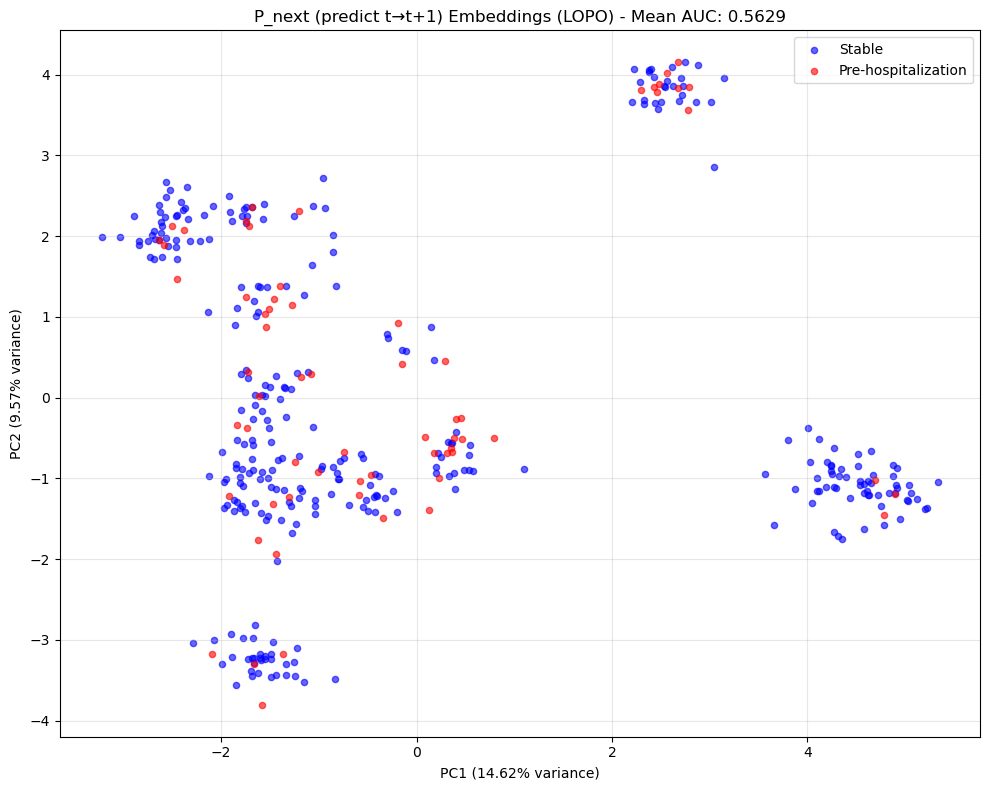

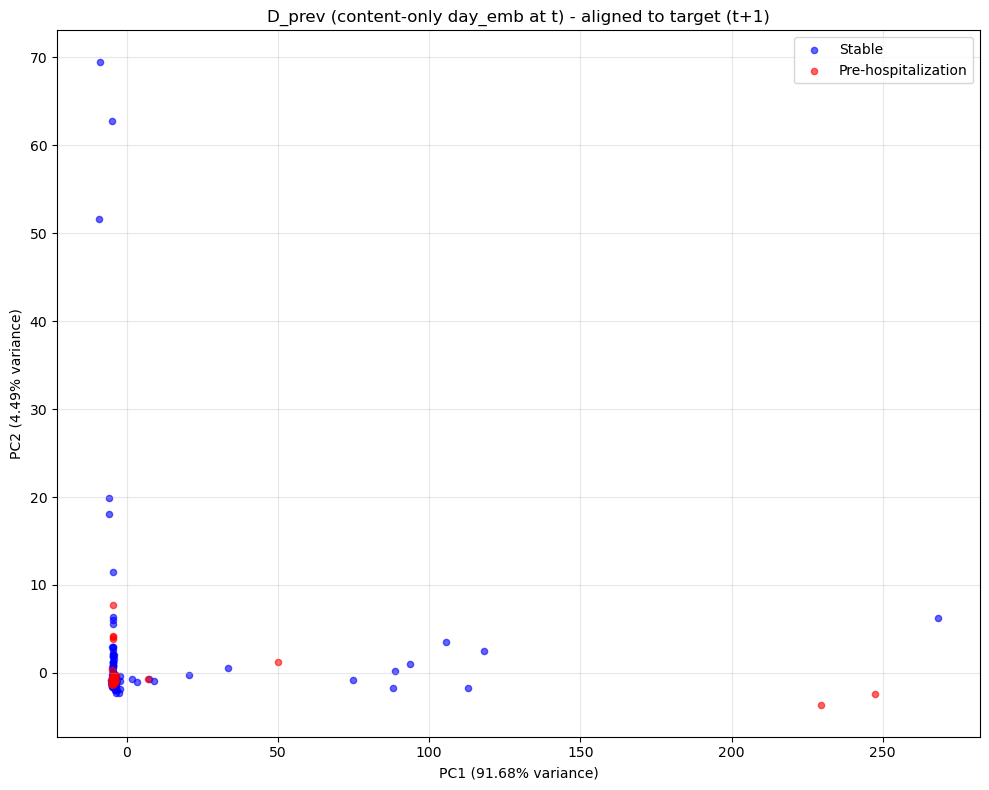

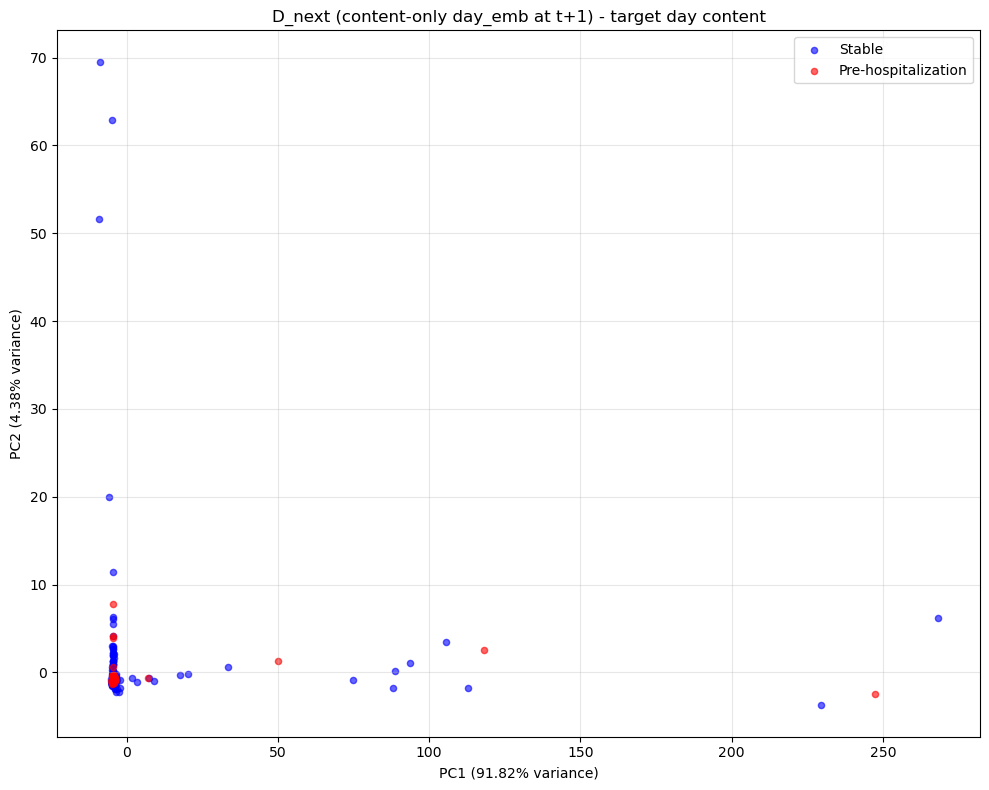

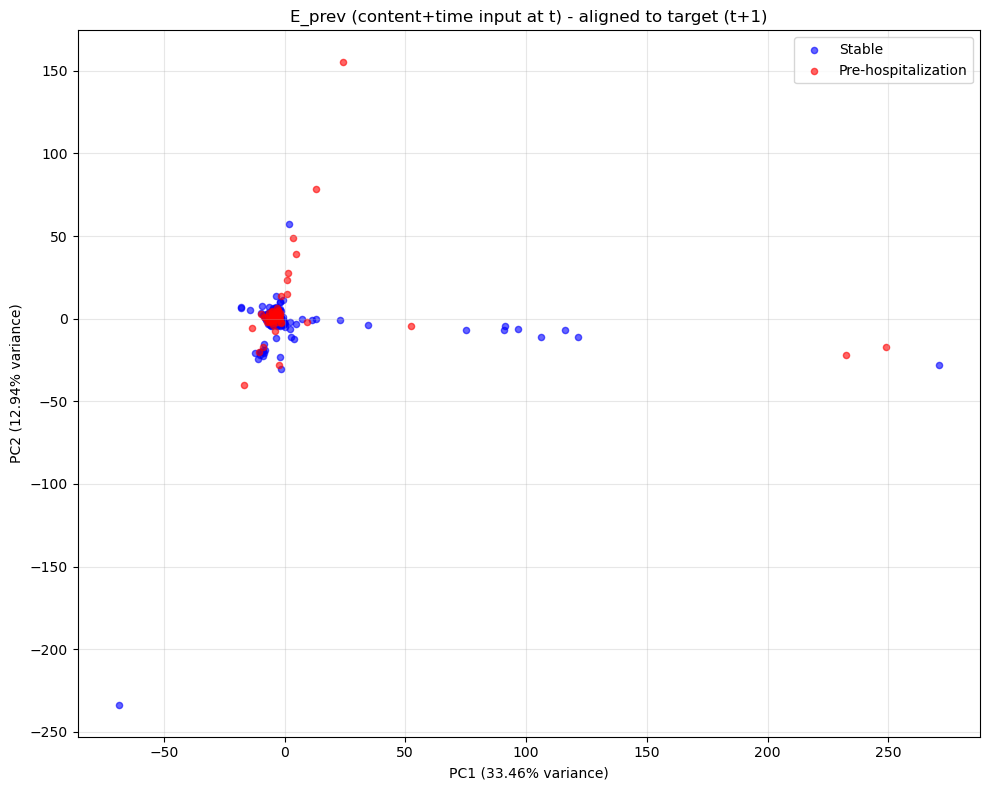

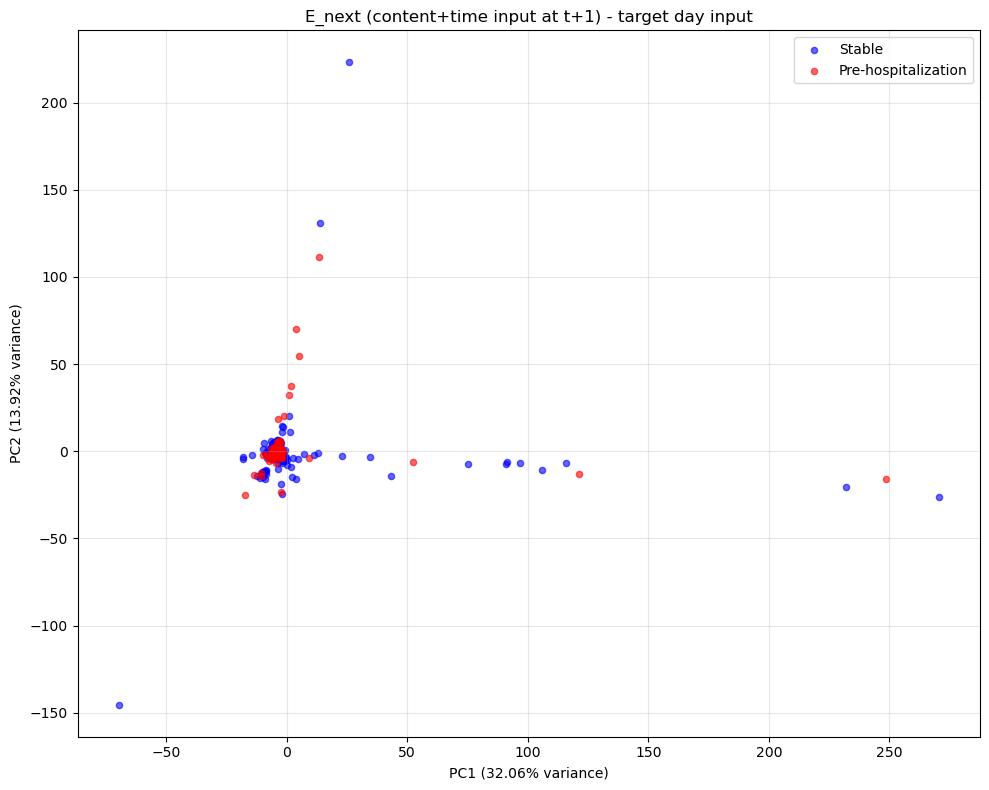

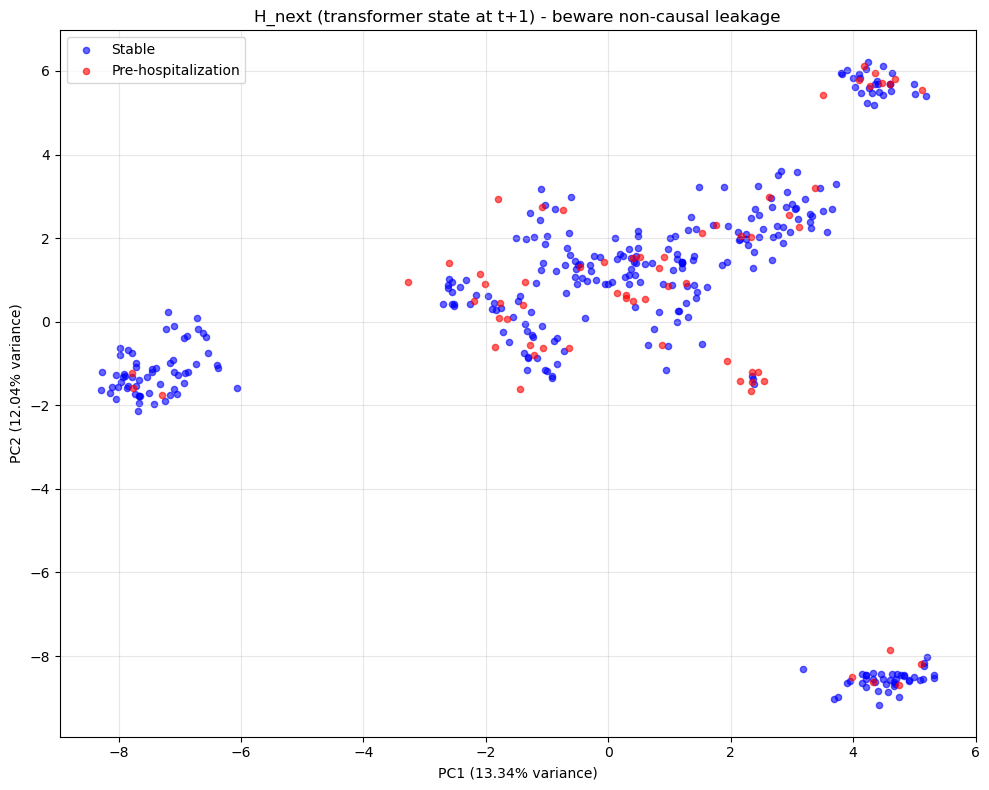


Training complete!
Final Mean ROC AUC: 0.5629 ± 0.2158
Embedding visualization saved in folder emb_vis


In [3]:
from train import (load_df, train_lopo)

DEVICE = "cuda" if (torch.cuda.is_available() and cfg.use_cuda) else "cpu"
print(f"Using device: {DEVICE}")

df, feature_cols = load_df(cfg.data_path)

# You’ll likely want to move S,C,stride,gap_days into cfg.py
results = train_lopo(
    df=df,
    feature_cols=feature_cols,
    chunk_hidden=cfg.chunk_hidden,
    day_dim=cfg.day_dim,
    gap_days=cfg.gap_days,
    max_T_emb=cfg.max_T_emb,
    dropout=cfg.dropout,
    batch_size=cfg.batch_size,
    num_epochs=cfg.num_epochs,
    learning_rate=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
    device=DEVICE,
    save_path="../emb_vis/"
)

print("\nTraining complete!")
print(f"Final Mean ROC AUC: {results['mean_auc']:.4f} ± {results['std_auc']:.4f}")
print("Embedding visualization saved in folder emb_vis")